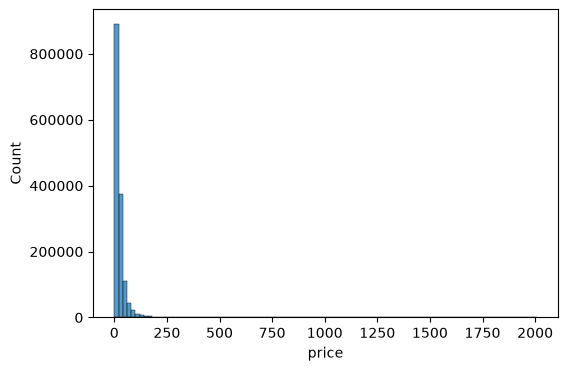

전처리 전 : (1482535, 8)
가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : (1481658, 8)
train_id 제거 및 중복 제거 후 : (1481609, 7)


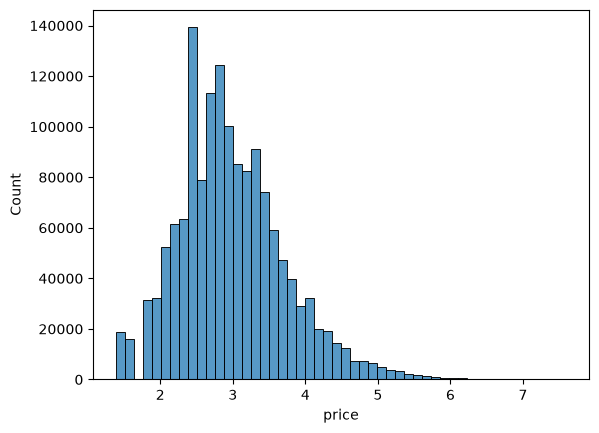

In [1]:
#데이터 불러오기

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

RANDOM_STATE = 42  # 재현성을 위해 랜덤값 고정

mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')

# 가격 분포 확인
y_labels = mercari_df['price']
plt.figure(figsize=(6, 4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()

# 가격 이상치 처리
# 1) 0원 이하: 무효 데이터라 제거
# 2) 2000달러 초과: Mercari 플랫폼의 실제 최대 등록가 정책(도메인 규칙) 기준 제거 - 0원 처리와 동일한 원칙
print(f'전처리 전 : {mercari_df.shape}')

mercari_df = mercari_df[(mercari_df['price'] > 0) & (mercari_df['price'] <= 2000)]
print(f'가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거 + 중복 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)
print(f'train_id 제거 및 중복 제거 후 : {mercari_df.shape}')

# 가격 로그 변환 (분포가 크게 치우쳐 있어 log1p 적용, 예측 후 expm1로 원래 스케일 복원 예정)
y_labels = mercari_df['price']
mercari_df['price'] = np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [2]:
# category_name 3단계 분리 (Main/Sub/SubSub) - 구조적 파싱이라 split 이전에 해도 leakage 없음
def split_category(df, col='category_name'):
    df = df.copy()
    df[col] = df[col].fillna('Unknown/Unknown/Unknown')
    parts = df[col].str.split('/', n=2, expand=True)
    parts.columns = ['cat_main', 'cat_sub', 'cat_sub2']
    parts = parts.fillna('Unknown')  # 3단계가 안 나온 행 보정
    return pd.concat([df, parts], axis=1)

mercari_df = split_category(mercari_df)
mercari_df[['category_name', 'cat_main', 'cat_sub', 'cat_sub2']].head()

,category_name,cat_main,cat_sub,cat_sub2
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


In [3]:
# 학습 / 테스트 데이터 분리
# 실제 test.tsv(정답 없는 제출용)가 아니라, 보유한 train 데이터를 직접 나눠서 검증에 사용한다.
# 이 시점 이후의 모든 "학습(fit)" 단계는 train_df에서만 수행하고 test_df에는 적용(transform)만 한다.
train_df, test_df = train_test_split(
    mercari_df, test_size=0.2, random_state=RANDOM_STATE
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'train_df : {train_df.shape}')
print(f'test_df  : {test_df.shape}')

train_df : (1185287, 10)
test_df  : (296322, 10)


In [4]:
# brand_name 결측치 채우기 - item_description 우선, 그래도 못 찾으면 name(상품명)에서도 탐색 (2단계 매칭)
# 어디서 채워졌는지 brand_source 컬럼에 기록해서 나중에 신뢰도 구분/표본 검증에 활용
# 주의: 아직 텍스트를 불용어 제거/토큰화하기 전(원문에 가까운 상태)에 매칭해야
#       "Kate Spade"처럼 여러 단어로 된 브랜드명이나 특수문자가 포함된 브랜드명이 깨지지 않는다.
#
# [개선] description 한 문장 안에 서로 다른 브랜드가 2개 이상 동시에 언급될 수 있다
# (예: "similar to Kate Spade quality, not Coach"). 이런 경우 그냥 먼저 나온 브랜드를 고르면
# 틀릴 수 있어서, 후보가 2개 이상이면 "문맥 유사도"를 계산해 더 그럴듯한 쪽을 고른다.
#
# 유사도 판단 순서: 1순위 카테고리(cat_main/cat_sub/cat_sub2) 문맥, 그래도 애매하면 2순위 name(상품명).
# 유사도 계산은 TF-IDF 코사인 유사도를 쓴다.
#   - TF-IDF 코사인 유사도: 두 문장을 "단어별 중요도 가중치가 반영된 벡터"로 바꾼 뒤,
#     그 벡터 사이의 각도(코사인 값)로 얼마나 비슷한 방향(=비슷한 단어 구성)을 향하는지를 0~1 사이 점수로 낸다.
#     흔한 단어에는 낮은 가중치를, 특징적인 단어에는 높은 가중치를 자동으로 매겨준다는 게 장점이다.
#   - (참고, 이번엔 안 쓰지만) Jaccard 유사도라는 대안도 있다: 두 문장을 그냥 "단어 집합"으로만 보고
#     (겹치는 단어 수) / (전체 고유 단어 수)로 계산하는 훨씬 단순한 방식이다. 계산은 가볍지만
#     단어 중요도를 전혀 구분 못 해서(흔한 단어 "the"와 특징적인 단어 "leather"를 똑같이 취급) 이번처럼
#     브랜드 문맥 비교엔 TF-IDF 코사인 유사도가 더 적합하다고 판단해 Jaccard는 사용하지 않는다.
# 임계값(SIMILARITY_THRESHOLD)을 넘는 후보가 하나도 없으면 억지로 고르지 않고 그냥 못 찾은 것으로 남겨서
# (이후 restrict_to_known 단계에서 자동으로) 'Unknown' 처리되게 한다 - 틀린 라벨을 강제로 채우는 것보다 안전.
from sklearn.metrics.pairwise import cosine_similarity

WINDOW_SIZE = 5              # 브랜드 후보 앞뒤로 몇 단어까지를 문맥으로 볼지
SIMILARITY_THRESHOLD = 0.15  # 이 값 미만이면 확신 없다고 보고 Unknown 처리

def build_known_brands(df, col='brand_name'):
    """train 데이터에서만 호출해야 함 - 이미 채워진 값들로 알려진 브랜드 목록 생성"""
    return sorted(df[col].dropna().unique().tolist())

def build_brand_pattern(known_brands):
    """긴 브랜드명이 먼저 매칭되도록 길이 내림차순 정렬 + 단어 경계(\\b) 정규식 컴파일"""
    sorted_brands = sorted([b for b in known_brands if len(b) > 0], key=len, reverse=True)
    escaped = [re.escape(b.lower()) for b in sorted_brands]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b')
    lower_to_original = {b.lower(): b for b in sorted_brands}
    return pattern, lower_to_original

def find_all_brand_candidates(text, pattern, lower_to_original, window=WINDOW_SIZE):
    """텍스트 안에서 나오는 (중복 제외) 모든 known 브랜드 후보와, 각 후보 주변의 문맥 윈도우를 찾는다.
    같은 브랜드가 여러 번 나와도 첫 등장 위치의 윈도우만 사용한다."""
    text_lower = str(text).lower()
    candidates = {}
    for match in pattern.finditer(text_lower):
        brand = lower_to_original[match.group(1)]
        if brand in candidates:
            continue
        start, end = match.span()
        before = ' '.join(text_lower[:start].split()[-window:])
        after = ' '.join(text_lower[end:].split()[:window])
        candidates[brand] = f'{before} {match.group(1)} {after}'.strip()
    return candidates

def resolve_ambiguous_brand(candidates, cat_context, name_context):
    """후보가 2개 이상일 때 카테고리 문맥(1순위) -> name(2순위) 순으로 TF-IDF 코사인 유사도를 비교해
    가장 그럴듯한 브랜드 하나를 고른다. 두 기준 다 임계값을 못 넘기면 None(Unknown 처리)을 반환한다."""
    brands = list(candidates.keys())
    windows = list(candidates.values())

    for reference in (cat_context, name_context):
        reference = str(reference).strip()
        if not reference:
            continue
        corpus = windows + [reference]
        try:
            vec = TfidfVectorizer().fit(corpus)
        except ValueError:
            continue  # 전부 짧은 단어뿐이라 vocabulary가 비는 극단적인 경우 등 - 다음 기준으로 넘어감
        matrix = vec.transform(corpus)
        sims = cosine_similarity(matrix[:-1], matrix[-1])[:, 0]
        best_idx = int(sims.argmax())
        if sims[best_idx] >= SIMILARITY_THRESHOLD:
            return brands[best_idx]
    return None

def fill_brand_with_source(df, pattern, lower_to_original, desc_col,
                            brand_col='brand_name', source_col='brand_source'):
    """brand_col이 NaN인 행에 대해서만 desc_col에서 브랜드를 탐색해 채우고,
    새로 채워진 행에는 source_col에 desc_col 이름을 기록한다 (매칭 출처 추적용).
    후보가 2개 이상이면 카테고리/name 문맥과의 유사도로 하나를 고르고,
    확신이 없으면(임계값 미달) 채우지 않고 그대로 NaN으로 남긴다."""
    df = df.copy()
    missing_mask = df[brand_col].isna()

    def find_brand(row):
        text = row[desc_col]
        text = '' if pd.isna(text) else text
        candidates = find_all_brand_candidates(text, pattern, lower_to_original)
        if len(candidates) == 0:
            return None
        if len(candidates) == 1:
            return next(iter(candidates))
        cat_context = ' '.join(str(row[c]) for c in ['cat_main', 'cat_sub', 'cat_sub2'])
        name_context = str(row['name'])
        return resolve_ambiguous_brand(candidates, cat_context, name_context)

    found = df.loc[missing_mask].apply(find_brand, axis=1)
    df.loc[missing_mask, brand_col] = found

    newly_filled_mask = missing_mask & df[brand_col].notna()
    df.loc[newly_filled_mask, source_col] = desc_col
    return df

# 1) train에서만 브랜드 사전 생성 (leakage 방지)
known_brands = build_known_brands(train_df)
brand_pattern, brand_lower_to_original = build_brand_pattern(known_brands)
print(f'train 기준 알려진 브랜드 수 : {len(known_brands)}')

# 2) brand_source 초기화 - 원래 값이 있던 행은 'original', 없는 행은 일단 'unmatched'
train_df['brand_source'] = np.where(train_df['brand_name'].notna(), 'original', 'unmatched')

# 3) 1차: item_description에서 매칭 (행 단위로 후보를 다 뽑아 유사도까지 따지는 방식이라
#    기존 방식(문장당 정규식 1회 탐색)보다 시간이 더 걸릴 수 있음 - 후보 2개 이상인 애매한 행만
#    TF-IDF 유사도 계산이 추가로 붙고, 나머지는 기존과 동일하게 빠르게 처리됨)
train_df = fill_brand_with_source(train_df, brand_pattern, brand_lower_to_original, desc_col='item_description')

# 4) 2차: 1차에서도 못 찾은 행만 name(상품명)에서 매칭
train_df = fill_brand_with_source(train_df, brand_pattern, brand_lower_to_original, desc_col='name')

print(train_df['brand_source'].value_counts())

# 5) 사전을 파일로 저장해두고 test/향후 데이터에는 이 파일을 불러와 "적용만" 한다
with open('brand_dictionary.pkl', 'wb') as f:
    pickle.dump(known_brands, f)


train 기준 알려진 브랜드 수 : 4535
brand_source
original            679614
item_description    226998
unmatched           190242
name                 88433
Name: count, dtype: int64


In [ ]:
# [검증] 길이 내림차순 정렬 덕분에 짧은 브랜드에 안 뺏기고 긴 브랜드가 먼저 매칭된 사례
# train_df['brand_source']에 이미 'item_description'/'name'이 찍혀 있는(=매칭으로 채워진) 행만 대상으로 한다.
# 실제 가격도 같이 보여준다 - '예측 가격'은 모델 학습이 끝난 뒤(맨 아래쪽 셀에서) 이 표에 이어붙인다.
# (order_indices에 원본 train_df 인덱스를 따로 보관해뒀다가 그때 X_train에서 같은 행을 다시 찾는다)

matched_rows = train_df[train_df['brand_source'].isin(['item_description', 'name'])]

def build_brand_pattern_naive(known_brands):
    """비교용: 길이 정렬 없이 known_brands 원래 순서(알파벳순) 그대로 컴파일한 패턴.
    '만약 length 정렬을 안 했다면 어떤 브랜드가 매칭됐을지'를 재현하기 위한 용도."""
    brands = [b for b in known_brands if len(b) > 0]
    escaped = [re.escape(b.lower()) for b in brands]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b')
    lower_to_original = {b.lower(): b for b in brands}
    return pattern, lower_to_original

naive_pattern, naive_lower_to_original = build_brand_pattern_naive(known_brands)

order_examples = []
order_indices = []  # 각 행의 원본 train_df 인덱스 (뒤에서 예측 가격 붙일 때 사용, 표에는 안 보여줌)
for _, row in matched_rows.iterrows():
    text = row[row['brand_source']]
    if pd.isna(text):
        continue
    naive_match = naive_pattern.search(str(text).lower())
    if naive_match is None:
        continue
    naive_brand = naive_lower_to_original[naive_match.group(1)]
    real_brand = row['brand_name']
    # 진짜 "하이재킹" 사례만 남긴다: naive_brand가 real_brand의 앞부분 단어와 정확히 겹칠 때
    # (예: real_brand='Kate Spade' 인데 naive_brand='Kate' 인 경우)
    if naive_brand != real_brand and real_brand.lower().startswith(naive_brand.lower() + ' '):
        order_examples.append({
            '상품명': row['name'],
            '매칭 근거 텍스트': text,
            '정렬 안 했다면 매칭됐을 브랜드': naive_brand,
            '실제로 채워진 브랜드(길이순 정렬)': real_brand,
            '실제 가격($)': round(np.expm1(row['price']), 2),  # price는 이미 log1p 스케일이라 복원
        })
        order_indices.append(row.name)
    if len(order_examples) >= 5:
        break

print('=== 길이 내림차순 정렬 덕분에 긴 브랜드가 먼저 매칭된 사례 ===')
print(f'(정렬을 안 했다면 더 짧고 부정확한 브랜드로 채워졌을 뻔한 경우 {len(order_examples)}건)')

pd.set_option('display.max_colwidth', 150)  # 매칭 근거 텍스트가 길어서 안 잘리게 넉넉히 표시
order_df = pd.DataFrame(order_examples)
order_df


In [ ]:
# [검증] 후보가 2개 이상이라 카테고리/상품명 문맥과의 TF-IDF 유사도로 브랜드를 하나 고른 사례
# (바로 위 셀에서 만든 matched_rows를 그대로 이어서 쓴다)
# 마찬가지로 실제 가격을 같이 보여주고, 예측 가격은 모델 학습 후 맨 아래쪽 셀에서 이어붙인다.

def resolve_ambiguous_brand_debug(candidates, cat_context, name_context):
    """resolve_ambiguous_brand와 완전히 동일한 로직이지만, 최종 선택 브랜드뿐 아니라
    후보별 유사도 점수와 어떤 기준(카테고리/name)으로 결정됐는지도 같이 반환한다 (설명용)."""
    brands = list(candidates.keys())
    windows = list(candidates.values())

    for ref_name, reference in [('category', cat_context), ('name', name_context)]:
        reference = str(reference).strip()
        if not reference:
            continue
        corpus = windows + [reference]
        try:
            vec = TfidfVectorizer().fit(corpus)
        except ValueError:
            continue
        matrix = vec.transform(corpus)
        sims = cosine_similarity(matrix[:-1], matrix[-1])[:, 0]
        best_idx = int(sims.argmax())
        if sims[best_idx] >= SIMILARITY_THRESHOLD:
            return {
                'chosen': brands[best_idx],
                'reference_used': ref_name,
                'reference_text': reference,
                'similarities': dict(zip(brands, sims.round(3))),
            }
    return {'chosen': None, 'reference_used': None, 'reference_text': None, 'similarities': {}}

ambiguous_examples = []
ambiguous_indices = []  # 각 행의 원본 train_df 인덱스 (뒤에서 예측 가격 붙일 때 사용, 표에는 안 보여줌)
for _, row in matched_rows.iterrows():
    text = row[row['brand_source']]
    if pd.isna(text):
        continue
    candidates = find_all_brand_candidates(text, brand_pattern, brand_lower_to_original)
    if len(candidates) < 2:
        continue
    cat_context = ' '.join(str(row[c]) for c in ['cat_main', 'cat_sub', 'cat_sub2'])
    name_context = str(row['name'])
    debug = resolve_ambiguous_brand_debug(candidates, cat_context, name_context)
    if debug['chosen'] != row['brand_name']:
        continue  # 이론상 항상 같아야 함(동일 로직 재실행) - 방어적으로만 걸러둠
    ambiguous_examples.append({
        '상품명': row['name'],
        '매칭 근거 텍스트': text,
        '후보 브랜드': ', '.join(candidates.keys()),
        '참고한 문맥': f"{debug['reference_used']} = '{debug['reference_text']}'",
        '후보별 유사도': ', '.join(f'{b}={s:.3f}' for b, s in debug['similarities'].items()),
        '최종 선택': debug['chosen'],
        '실제 가격($)': round(np.expm1(row['price']), 2),  # price는 이미 log1p 스케일이라 복원
    })
    ambiguous_indices.append(row.name)
    if len(ambiguous_examples) >= 5:
        break

print('=== 후보 2개 이상 -> 카테고리/상품명 문맥 유사도로 브랜드를 고른 사례 ===')
print(f'(문장 하나에 알려진 브랜드가 2개 이상 동시에 등장했던 경우 {len(ambiguous_examples)}건)')

ambiguous_df = pd.DataFrame(ambiguous_examples)
ambiguous_df


In [5]:
# test_df에는 train에서 만든 사전을 "적용만" 한다 (사전을 새로 만들지 않음)
# train과 동일하게 brand_source 초기화 + 2단계 매칭(item_description → name) 적용
test_df['brand_source'] = np.where(test_df['brand_name'].notna(), 'original', 'unmatched')
test_df = fill_brand_with_source(test_df, brand_pattern, brand_lower_to_original, desc_col='item_description')
test_df = fill_brand_with_source(test_df, brand_pattern, brand_lower_to_original, desc_col='name')

print(test_df['brand_source'].value_counts())

# train 사전에 없는 브랜드는 test에서 원래 값으로 존재했든 description/name 매칭으로 채워졌든
# 전부 'Unknown'으로 통일한다 (인코딩 단계의 unseen category 문제 방지)
# brand_source는 "어디서 찾았는지" 기록이라 이 Unknown 통일과는 별개로 그대로 유지한다.
# 여기서의 NaN에는 두 가지 경우가 섞여 있다: (1) description/name 어디서도 브랜드 후보를 못 찾은 경우
# (2) 후보가 2개 이상이었지만 유사도가 SIMILARITY_THRESHOLD를 못 넘겨서 확신 없이 넘어간 경우.
# 둘 다 결과적으로는 같은 'Unknown'으로 처리된다.
known_brands_set = set(known_brands)

def restrict_to_known(series, known_set, unknown_value='Unknown'):
    return series.where(series.isin(known_set) & series.notna(), unknown_value)

train_df['brand_name'] = restrict_to_known(train_df['brand_name'], known_brands_set)
test_df['brand_name'] = restrict_to_known(test_df['brand_name'], known_brands_set)

# category_name도 동일한 원칙 적용: train에 등장한 조합만 known set으로 인정
for col in ['cat_main', 'cat_sub', 'cat_sub2']:
    known_cats = set(train_df[col].unique())
    test_df[col] = restrict_to_known(test_df[col], known_cats)

print('brand_name 결측치 (train):', train_df['brand_name'].isna().sum())
print('brand_name 결측치 (test) :', test_df['brand_name'].isna().sum())
print(train_df['brand_name'].value_counts().head())

# [확인] 유사도 임계값을 넘지 못했거나 애초에 후보를 못 찾아서 최종 Unknown으로 남은 행 수
print()
print('brand_name == Unknown (train):', (train_df['brand_name'] == 'Unknown').sum())
print('brand_name == Unknown (test) :', (test_df['brand_name'] == 'Unknown').sum())


brand_source
original            169700
item_description     57127
unmatched            47324
name                 22171
Name: count, dtype: int64
brand_name 결측치 (train): 0
brand_name 결측치 (test) : 0
brand_name
Unknown    190242
AND         74221
PINK        56437
Nike        45025
LuLaRoe     43863
Name: count, dtype: int64

brand_name == Unknown (train): 190242
brand_name == Unknown (test) : 47617


In [20]:
# 오탐 브랜드 스크리닝 - "매칭 비율" 계산
# 진짜 브랜드라면 원래(original)도 어느 정도 있어야 정상. 'and'처럼 흔한 단어는
# original은 적은데 description/name 매칭으로만 폭발적으로 늘어나는 특징을 보임 -> 이 비율로 자동 스크리닝.
combined = pd.concat([train_df, test_df])

brand_source_by_brand = (
    combined.groupby(['brand_name', 'brand_source']).size().unstack(fill_value=0)
)
for col in ['original', 'item_description', 'name']:
    if col not in brand_source_by_brand.columns:
        brand_source_by_brand[col] = 0

brand_source_by_brand['matched_total'] = brand_source_by_brand['item_description'] + brand_source_by_brand['name']
brand_source_by_brand['매칭배율'] = brand_source_by_brand['matched_total'] / (brand_source_by_brand['original'] + 1)

# 여러 단어로 된 브랜드(예: Kate Spade)는 우연히 통째로 매칭될 확률이 낮아 상대적으로 안전 -> 한 단어짜리만 스크리닝
single_word_brands = [b for b in brand_source_by_brand.index if isinstance(b, str) and ' ' not in b and b != 'Unknown']
suspects = brand_source_by_brand.loc[single_word_brands].sort_values('매칭배율', ascending=False)

In [21]:
suspects[['original', 'item_description', 'name', 'matched_total', '매칭배율']].head(20)

brand_source,original,item_description,name,matched_total,매칭배율
brand_name,,,,,
AND,3,86142,6676,92818,23204.500000
BLUE,1,8309,2684,10993,5496.500000
X,1,4546,688,5234,2617.000000
Silver,3,7120,1779,8899,2224.750000
Ask,1,2710,10,2720,1360.000000
Diamond,1,1173,554,1727,863.500000
Key,1,679,222,901,450.500000
Pro,2,893,440,1333,444.333333
Complete,2,1088,206,1294,431.333333


In [7]:
# 추가 feature 1: 설명 유무 플래그 / 텍스트 길이
# 반드시 텍스트 클렌징(토큰화) 이전, 원문 상태에서 계산해야 함
for df in (train_df, test_df):
    df['has_description'] = (
        df['item_description'].fillna('No description yet') != 'No description yet'
    ).astype(int)
    df['name_len'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
    df['desc_len'] = df['item_description'].fillna('No description yet').apply(lambda x: len(str(x).split()))

print(train_df[['has_description', 'name_len', 'desc_len']].describe())

       has_description      name_len      desc_len
count     1.185287e+06  1.185287e+06  1.185287e+06
mean      9.444759e-01  4.400638e+00  2.567726e+01
std       2.290005e-01  1.654930e+00  3.038149e+01
min       0.000000e+00  1.000000e+00  1.000000e+00
25%       1.000000e+00  3.000000e+00  7.000000e+00
50%       1.000000e+00  4.000000e+00  1.500000e+01
75%       1.000000e+00  6.000000e+00  3.100000e+01
max       1.000000e+00  1.700000e+01  2.450000e+02


In [8]:
# 텍스트 전처리 유틸 함수 (item_description, name 공통 사용)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def text_cleaning(text):
    # 소문자로 변환
    text = text.lower()
    # 영문자/숫자/공백을 제외한 문자 제거 ([rm] 마스킹 토큰의 대괄호도 여기서 제거됨)
    # 숫자는 제거하지 않음 - 4gb, 32gb, 사이즈 등 가격에 영향을 줄 수 있는 정보라 보존
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
# (버그 수정: 기존 코드는 'never'와 'without' 사이에 콤마가 빠져 있어서
#  파이썬이 두 문자열을 'neverwithout' 하나로 합쳐버렸음 -> 콤마 추가로 수정)
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}
stop_words = stop_words - negative_words

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

def preprocess_text(text):
    # 1. 소문자 / 영문자 / 숫자 / 공백 정리
    text = text_cleaning(text)
    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)
    # 3. 불용어 제거
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [9]:
# item_description, name 클렌징 적용 (train_df, test_df 각각에 동일하게 적용 - 순수 per-row 변환이라 leakage 없음)
# 데이터 규모가 커서 시간이 다소 걸릴 수 있음 (수 분 단위)

def clean_text_columns(df):
    df = df.copy()
    df['item_description'] = df['item_description'].fillna('No description yet').astype(str)
    df['name'] = df['name'].fillna('').astype(str)

    df['item_description'] = df['item_description'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    df['name'] = df['name'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    return df

train_df = clean_text_columns(train_df)
test_df = clean_text_columns(test_df)

train_df[['name', 'item_description']].head()

,name,item_description
0,forever 21 sundress,nwts forever 21 purple sundress shoulder size
1,bundle pants,bundle pants good condition except green ones ...
2,peach shirt free ship,size medium plain 3 4 sleeve peach colored top...
3,bundle kalislp,item worn no holes tears minor pulls
4,new bikini lot 2 sz sm free shipping,awesome brazilian bikinis one black one teal s...


In [10]:
# item_description / name 텍스트 벡터화 (TfidfVectorizer)
# 원칙: train으로만 fit(), test는 transform()만 - 새 단어는 에러 없이 그냥 무시됨
name_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
desc_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_name_train = name_vectorizer.fit_transform(train_df['name'])
X_name_test = name_vectorizer.transform(test_df['name'])

X_desc_train = desc_vectorizer.fit_transform(train_df['item_description'])
X_desc_test = desc_vectorizer.transform(test_df['item_description'])

print('name 벡터 shape       :', X_name_train.shape, X_name_test.shape)
print('description 벡터 shape:', X_desc_train.shape, X_desc_test.shape)

# 벡터라이저 객체 저장 (brand 사전과 동일한 관리 방식 - 재사용을 위해 fit된 객체 자체를 보존)
with open('name_vectorizer.pkl', 'wb') as f:
    pickle.dump(name_vectorizer, f)
with open('desc_vectorizer.pkl', 'wb') as f:
    pickle.dump(desc_vectorizer, f)

name 벡터 shape       : (1185287, 30000) (296322, 30000)
description 벡터 shape: (1185287, 50000) (296322, 50000)


In [11]:
# brand_name / category 원-핫 인코딩
# handle_unknown='ignore' -> train에 없던 값이 test에 나와도 에러 없이 전부 0벡터로 처리됨
# (이미 restrict_to_known으로 'Unknown' 통일까지 해뒀지만, 이중 안전장치로 추가)
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['brand_name', 'cat_main', 'cat_sub', 'cat_sub2']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat_train = ohe.fit_transform(train_df[cat_cols])
X_cat_test = ohe.transform(test_df[cat_cols])

print('카테고리 원-핫 shape :', X_cat_train.shape, X_cat_test.shape)

with open('cat_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)

카테고리 원-핫 shape : (1185287, 5527) (296322, 5527)


In [12]:
# 수치형 피처 스케일링 (item_condition_id + 신규 추가 feature 3개)
# GBM은 스케일에 둔감하지만 베이스라인 선형회귀(Ridge)를 위해 표준화한다.
# shipping은 이미 0/1 이진값이라 스케일링 대상에서 제외.
# brand_target_enc는 실험 결과(다중공선성 확인) 원-핫만 쓰는 것보다 안 좋아서 최종 제외함.
numeric_cols = ['item_condition_id', 'has_description', 'name_len', 'desc_len']

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_num_test = scaler.transform(test_df[numeric_cols])

print('수치형 스케일링 shape :', X_num_train.shape, X_num_test.shape)

with open('numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

수치형 스케일링 shape : (1185287, 4) (296322, 4)


In [13]:
# 최종 feature 결합 + 전체 전처리 파이프라인을 하나로 묶기
from scipy.sparse import csr_matrix, hstack

def combine_features(X_cat, X_num, shipping_series, X_name, X_desc):
    X_ship = csr_matrix(shipping_series.values.reshape(-1, 1))
    return hstack([X_cat, X_num, X_ship, X_name, X_desc]).tocsr()

X_train = combine_features(X_cat_train, X_num_train, train_df['shipping'], X_name_train, X_desc_train)
X_test = combine_features(X_cat_test, X_num_test, test_df['shipping'], X_name_test, X_desc_test)

y_train = train_df['price'].values  # 이미 log1p 적용된 값
y_test = test_df['price'].values

print('X_train :', X_train.shape, ' X_test :', X_test.shape)

# 학습 때 사용한 모든 전처리 객체를 하나의 아티팩트로 묶어서 저장한다.
# -> 이후 새 상품 하나(또는 새 데이터셋)가 들어와도 이 파일 하나만 불러와서
#    preprocess_new_data()에 통과시키면 학습 때와 완전히 동일한 형식의 feature가 나온다.
pipeline_artifacts = {
    'known_brands': known_brands,
    'brand_pattern': brand_pattern,
    'brand_lower_to_original': brand_lower_to_original,
    'known_brands_set': known_brands_set,
    'known_cats': {col: set(train_df[col].unique()) for col in cat_cols},
    'stop_words': stop_words,
    'cat_encoder': ohe,
    'numeric_scaler': scaler,
    'name_vectorizer': name_vectorizer,
    'desc_vectorizer': desc_vectorizer,
    'numeric_cols': numeric_cols,
    'cat_cols': cat_cols,
}

with open('mercari_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_artifacts, f)


def preprocess_new_data(raw_df, artifacts=pipeline_artifacts):
    """새로 들어온 원본 데이터(raw_df)에 학습 때와 동일한 전처리를 그대로 적용해
    모델 입력용 희소행렬을 반환한다. (train 재학습 없이 저장된 아티팩트만 사용)"""
    df = raw_df.copy()

    # 1) category 3분할
    df = split_category(df)

    # 2) brand_name 결측치 채우기 - item_description 우선, 못 찾으면 name도 탐색 (train/test와 동일한 2단계 매칭)
    df['brand_source'] = np.where(df['brand_name'].notna(), 'original', 'unmatched')
    df = fill_brand_with_source(df, artifacts['brand_pattern'], artifacts['brand_lower_to_original'], desc_col='item_description')
    df = fill_brand_with_source(df, artifacts['brand_pattern'], artifacts['brand_lower_to_original'], desc_col='name')
    df['brand_name'] = restrict_to_known(df['brand_name'], artifacts['known_brands_set'])
    for col in ['cat_main', 'cat_sub', 'cat_sub2']:
        df[col] = restrict_to_known(df[col], artifacts['known_cats'][col])

    # 3) 추가 feature (has_description / 텍스트 길이) - 전부 원문 상태에서 계산
    #    brand_target_enc는 실험 결과 성능/해석 둘 다 원-핫만 쓰는 것보다 안 좋아서 최종 제외함.
    df['has_description'] = (df['item_description'].fillna('No description yet') != 'No description yet').astype(int)
    df['name_len'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
    df['desc_len'] = df['item_description'].fillna('No description yet').apply(lambda x: len(str(x).split()))

    # 4) 텍스트 클렌징 (name, item_description)
    df = clean_text_columns(df)

    # 5) 인코딩 / 벡터화 / 스케일링 (전부 transform만 수행)
    X_cat = artifacts['cat_encoder'].transform(df[artifacts['cat_cols']])
    X_num = artifacts['numeric_scaler'].transform(df[artifacts['numeric_cols']])
    X_name = artifacts['name_vectorizer'].transform(df['name'])
    X_desc = artifacts['desc_vectorizer'].transform(df['item_description'])

    return combine_features(X_cat, X_num, df['shipping'], X_name, X_desc)

X_train : (1185287, 85532)  X_test : (296322, 85532)


In [14]:
# 평가지표: RMSLE
# y_train/y_test가 이미 log1p(price)이므로, 로그 스케일에서의 RMSE가 곧 RMSLE와 수학적으로 동일하다.
# rmsle(price_pred, price_true) = sqrt(mean((log1p(price_pred)-log1p(price_true))^2))
#                                = sqrt(mean((pred_log - true_log)^2))  <- 이미 log1p된 값끼리 비교
from sklearn.metrics import mean_squared_error

def rmsle_on_log_scale(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [15]:
# 베이스라인 모델: Ridge 회귀
# feature가 85,529개라 과적합 방지용으로 L2 정규화가 있는 Ridge 사용
ridge = Ridge(alpha=1.0)  # alpha: 정규화 강도

ridge.fit(X_train, y_train)  # 계수 학습

ridge_pred = ridge.predict(X_test)  # 예측값 (아직 log1p 스케일)

ridge_rmsle = rmsle_on_log_scale(y_test, ridge_pred)  # log 스케일 RMSE = RMSLE

print(f'[Ridge baseline] RMSLE : {ridge_rmsle:.5f}')  # GBM과 비교할 기준점

[Ridge baseline] RMSLE : 0.45381


       version  ridge_rmsle
digits removed      0.45892
   digits kept      0.45381
차이: -0.00511  (digits kept가 더 좋음)


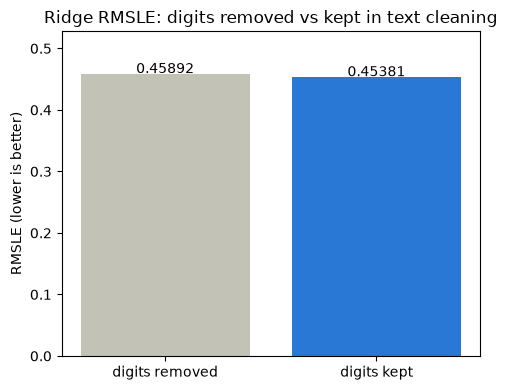

In [16]:
# 숫자 제거 vs 숫자 유지 - Ridge RMSLE 비교
# '숫자 유지'는 바로 위 Ridge 셀에서 방금 학습된 실제 ridge_rmsle 값 (현재 text_cleaning 기준).
# '숫자 제거'는 동일 파이프라인(train_test_split random_state=42, 동일 brand/category 전처리)에서
# text_cleaning 정규식만 [^a-z\s] (숫자 제거)로 되돌려 별도로 검증했던 결과값 (고정 기록값).
digit_removed_rmsle = 0.45892
digit_kept_rmsle = ridge_rmsle

comparison = pd.DataFrame({
    'version': ['digits removed', 'digits kept'],
    'ridge_rmsle': [digit_removed_rmsle, digit_kept_rmsle],
})
print(comparison.to_string(index=False))

diff = digit_kept_rmsle - digit_removed_rmsle
better = 'digits kept' if digit_kept_rmsle < digit_removed_rmsle else 'digits removed'
print(f'차이: {diff:+.5f}  ({better}가 더 좋음)')

plt.figure(figsize=(5, 4))
bars = plt.bar(comparison['version'], comparison['ridge_rmsle'], color=['#c3c2b7', '#2a78d6'])
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge RMSLE: digits removed vs kept in text cleaning')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001, f'{b.get_height():.5f}', ha='center')
plt.ylim(0, max(comparison['ridge_rmsle']) * 1.15)
plt.tight_layout()
plt.show()

alpha=1    RMSLE=0.45381
alpha=2    RMSLE=0.45265
alpha=3    RMSLE=0.45225
alpha=4    RMSLE=0.45221
alpha=5    RMSLE=0.45237

best alpha = 4.0 (RMSLE 0.45221)


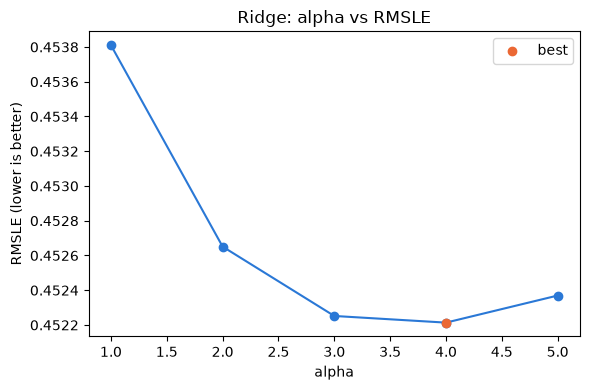

In [17]:
# Ridge alpha 값별 성능 비교 (1, 2, 3, 4, 5)
alphas = [1, 2, 3, 4, 5]
alpha_results = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    pred = r.predict(X_test)
    rmsle = rmsle_on_log_scale(y_test, pred)
    alpha_results.append({'alpha': a, 'rmsle': rmsle})
    print(f'alpha={a:<4} RMSLE={rmsle:.5f}')

alpha_df = pd.DataFrame(alpha_results)
best_row = alpha_df.loc[alpha_df['rmsle'].idxmin()]
print(f"\nbest alpha = {best_row['alpha']} (RMSLE {best_row['rmsle']:.5f})")

plt.figure(figsize=(6, 4))
plt.plot(alpha_df['alpha'], alpha_df['rmsle'], marker='o', color='#2a78d6')
plt.scatter([best_row['alpha']], [best_row['rmsle']], color='#eb6834', zorder=5, label='best')
plt.xlabel('alpha')
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge: alpha vs RMSLE')
plt.legend()
plt.tight_layout()
plt.show()

                           group  n_features  sum_abs_weight  mean_abs_weight
                     description       50000     8516.735185         0.170335
                            name       30000     5956.177519         0.198539
                      brand_name        4536      899.646196         0.198335
                        category         991      154.226864         0.155628
numeric (condition/has_desc/len)           4        0.225492         0.056373
                        shipping           1        0.186055         0.186055

          feature      coef
item_condition_id -0.086238
         name_len  0.072977
         desc_len  0.044993
  has_description  0.021283


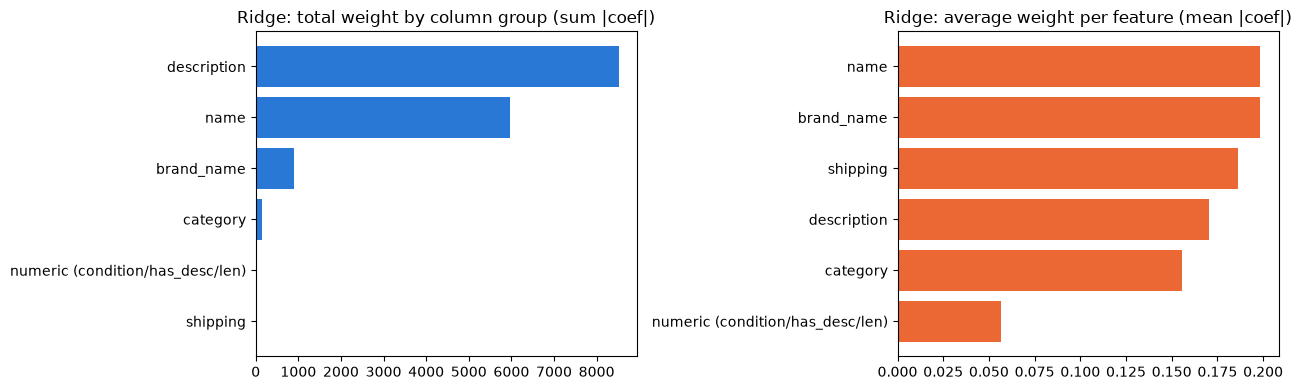

In [18]:
# Ridge 계수(coef_)를 6개 컬럼 그룹(brand_name / category / numeric / shipping / name / description)으로
# 묶어서 그룹별 대표 가중치를 확인한다. X_train을 hstack한 순서(cat, num, ship, name, desc) 그대로 슬라이싱.
# 'numeric' 그룹은 [item_condition_id, has_description, name_len, desc_len] 4개를 합친 블록이다.
# (brand_target_enc는 다중공선성 확인 실험 결과 제외했음)

cat_lengths = [len(c) for c in ohe.categories_]  # cat_cols = ['brand_name','cat_main','cat_sub','cat_sub2'] 순서
n_brand = cat_lengths[0]
n_category = sum(cat_lengths[1:])  # cat_main + cat_sub + cat_sub2 를 'category' 하나로 묶음

offset = 0
brand_coef = ridge.coef_[offset:offset+n_brand]; offset += n_brand
category_coef = ridge.coef_[offset:offset+n_category]; offset += n_category
numeric_coef = ridge.coef_[offset:offset+X_num_train.shape[1]]; offset += X_num_train.shape[1]
shipping_coef = ridge.coef_[offset:offset+1]; offset += 1
name_coef = ridge.coef_[offset:offset+X_name_train.shape[1]]; offset += X_name_train.shape[1]
desc_coef = ridge.coef_[offset:offset+X_desc_train.shape[1]]; offset += X_desc_train.shape[1]

assert offset == len(ridge.coef_), 'offset이 전체 계수 길이와 안 맞음 - 슬라이싱 순서 확인 필요'

groups = {
    'brand_name': brand_coef,
    'category': category_coef,
    'numeric (condition/has_desc/len)': numeric_coef,
    'shipping': shipping_coef,
    'name': name_coef,
    'description': desc_coef,
}

weight_summary = pd.DataFrame({
    'group': list(groups.keys()),
    'n_features': [len(v) for v in groups.values()],
    'sum_abs_weight': [np.abs(v).sum() for v in groups.values()],
    'mean_abs_weight': [np.abs(v).mean() for v in groups.values()],
}).sort_values('sum_abs_weight', ascending=False)

print(weight_summary.to_string(index=False))

# numeric 그룹 4개는 각각 개별 가중치도 따로 확인 (묶어놓으면 안 보이니까)
numeric_detail = pd.DataFrame({
    'feature': numeric_cols,
    'coef': numeric_coef,
}).sort_values('coef', key=np.abs, ascending=False)
print()
print(numeric_detail.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order1 = weight_summary.sort_values('sum_abs_weight')
axes[0].barh(order1['group'], order1['sum_abs_weight'], color='#2a78d6')
axes[0].set_title('Ridge: total weight by column group (sum |coef|)')

order2 = weight_summary.sort_values('mean_abs_weight')
axes[1].barh(order2['group'], order2['mean_abs_weight'], color='#eb6834')
axes[1].set_title('Ridge: average weight per feature (mean |coef|)')

plt.tight_layout()
plt.show()

In [19]:
# 최종 모델: Ridge만 사용 (Lasso/ElasticNet은 제거)
# 이전에 RidgeCV/LassoCV/ElasticNetCV를 다 비교해본 결과 Ridge가 계속 제일 좋았고
# (RidgeCV RMSLE 0.45202 vs LassoCV 0.53942 vs ElasticNetCV 0.49954), 이번 과제에서는
# Ridge만 쓰기로 확정했으므로 Lasso/ElasticNet 관련 코드는 전부 제거한다.
# alpha도 다시 탐색하지 않고, 이전 RidgeCV 탐색에서 이미 찾아둔 최적값(alpha=3.1623)을 그대로 사용한다.
# (brand_name 채움 로직이 유사도 기반으로 바뀌면서 X_train이 새로 만들어졌기 때문에, 엄밀히는
#  최적 alpha가 살짝 달라질 수 있지만 유의미한 차이는 아닐 것으로 보고 재탐색은 생략한다.)
BEST_ALPHA = 3.1623

ridge_final = Ridge(alpha=BEST_ALPHA)
ridge_final.fit(X_train, y_train)
ridge_final_rmsle = rmsle_on_log_scale(y_test, ridge_final.predict(X_test))

print(f'[Ridge final] alpha = {BEST_ALPHA}  RMSLE = {ridge_final_rmsle:.5f}')


[Ridge final] alpha = 3.1623  RMSLE = 0.45223


In [ ]:
# [검증 마무리] 앞에서 만든 두 사례표(order_df / ambiguous_df)에 최종 모델(ridge_final)의 예측 가격을 이어붙인다.
# 그때 따로 저장해둔 order_indices / ambiguous_indices(원본 train_df 인덱스)로 X_train에서 같은 행을 다시 찾는다.
# 주의: train_df 행이라 모델이 학습 때 이미 본 데이터(in-sample)다 - 모델의 진짜 일반화 성능을 보려는 게 아니라
#       "브랜드가 이렇게 채워진 상품의 가격이 실제로 얼마나 맞았는지" 사례를 눈으로 확인하려는 목적이라 이걸로 충분하다.
#       (완전히 새 데이터에 대한 정직한 성능 평가는 바로 아래 test_df 기반 비교 섹션에서 따로 확인한다.)
from IPython.display import display

def attach_predicted_price(df, indices):
    df = df.copy()
    pred_log = ridge_final.predict(X_train[indices])
    df['예측 가격($)'] = np.round(np.expm1(pred_log), 2)
    df['차이($)'] = (df['예측 가격($)'] - df['실제 가격($)']).round(2)
    return df

order_df = attach_predicted_price(order_df, order_indices)
ambiguous_df = attach_predicted_price(ambiguous_df, ambiguous_indices)

print('=== (1) 길이 정렬 사례 - 실제 가격 vs 예측 가격 ===')
display(order_df)

print('\n=== (2) 후보 2개 이상 사례 - 실제 가격 vs 예측 가격 ===')
display(ambiguous_df)


In [ ]:
# 실제 가격 vs 예측 가격 비교 (최종 Ridge 모델 ridge_final 기준)
# y_test / predict() 결과 둘 다 log1p 스케일이므로, expm1로 원래 달러 스케일로 복원한 뒤 비교한다.
actual_price = np.expm1(y_test)
predicted_price = np.expm1(ridge_final.predict(X_test))

price_compare = pd.DataFrame({
    '상품명': test_df['name'],
    '실제 가격': actual_price.round(2),
    '예측 가격': predicted_price.round(2),
})
price_compare['차이(예측-실제)'] = (price_compare['예측 가격'] - price_compare['실제 가격']).round(2)
price_compare['오차율(%)'] = (price_compare['차이(예측-실제)'] / price_compare['실제 가격'] * 100).round(1)

print(f'평균 절대 오차(MAE) : ${price_compare["차이(예측-실제)"].abs().mean():.2f}')
print(f'중앙값 절대 오차     : ${price_compare["차이(예측-실제)"].abs().median():.2f}')
print(f'평균 오차(부호 포함) : ${price_compare["차이(예측-실제)"].mean():+.2f}  (양수면 평균적으로 비싸게 예측)')

# 무작위 표본 15개 (실제 가격 순 정렬) - RMSLE 숫자 하나로는 안 보이던 "실제 얼마나 다른지" 감을 잡기 위함
price_compare.sample(15, random_state=RANDOM_STATE).sort_values('실제 가격')


In [ ]:
# 실제 가격 vs 예측 가격 - 전체 테스트셋을 그림으로 확인
# 왼쪽: 산점도 (점이 대각선 y=x에 가까울수록 정확한 예측). 오른쪽: 오차(예측-실제) 분포.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_price, predicted_price, alpha=0.05, s=8, color='#2a78d6')
max_val = 200  # 가격 대부분이 이 구간에 몰려 있어(하위 90%+) 보기 편하게 축을 제한함 - 실제 최대값은 2000
axes[0].plot([0, max_val], [0, max_val], color='#eb6834', linewidth=1.5, label='y = x (완벽한 예측)')
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].set_xlabel('실제 가격 ($)')
axes[0].set_ylabel('예측 가격 ($)')
axes[0].set_title('실제 vs 예측 (산점도)')
axes[0].legend()

sns.histplot(price_compare['차이(예측-실제)'], bins=100, ax=axes[1], color='#2a78d6')
axes[1].set_xlim(-100, 100)
axes[1].axvline(0, color='#eb6834', linestyle='--', label='오차 0 (정확히 맞춘 지점)')
axes[1].set_xlabel('예측 오차 ($) = 예측 가격 - 실제 가격')
axes[1].set_title('오차 분포 (0 근처에 몰릴수록 좋음)')
axes[1].legend()

plt.tight_layout()
plt.show()
